# 01 - Order Statistics: From Ranking to Counting

This notebook investigates why a probability involving an order statistis can be rewritten as a counting problem involving the original observations.

The main question is:

> Why does the event $Y_{(r)} \le y$ mean that at least $r$ observations must be less than or equal to $r$?

I will investigate this question using a concrete example, a Binomial model, a hand calculation, and a Python simulation.

## Goal / Question

Sppose the original observations are

$$
X_1, X_2, \ldots, X_n
$$

and their sorted values are

$$
Y_{(1)} \le Y_{(2)} \le \cdots \le Y_{(n)}.
$$

The value $Y_{(r)}$ is the $r$-th smallest observation.

The main relationship I want to understand is

$$
Y_{(r)} \le y
\quad\Longleftrightarrow\quad
\#\{X_i \le y\} \ge r.
$$

In words, I want to understand why saying that the $r$-th smallest observation is below a threashold is equivalent to saying that at least $r$ original observations are below that threashold.

## Hypothesis

I expect that the key is not the exact position of every observation, but the number of observations that fall below the threshold.

## Confusion Map

Before investigating the problem, I want to record the points that were confusing to me.

| Question | My initial understanding |
|---|---|
| What does $Y_{(4)}$ represent? | The fourth smallest observation |
| What does $Y_{(4)} \le 0.5$ mean? | I initially thought exactly four observations must be $\le 0.5$ |
| Why does the Binomial distribution appear? | I understood Binomial probability separately, but not its connection to order statistics |
| Why do we calculate $F(y)$? | I did not clearly understand that it becomes the success probability for each observation |
| Why integrate only up to $y$? | I confused the CDF with integrating over the entire support |

The most important confusion is the difference between **exactly $r$ observation** and **at least $r$ observations**.

## Minimal Background

### Order Stattistics

Given observations

$$
X_1, X_2, \ldots, X_n,
$$

we sort them from smallest to largest:

$$
Y_{(1)} \le Y_{(2)} \le \cdots \le Y_{(n)}.
$$

Therefore, 

- $Y_{(1)}$ is the minimum,
- $Y_{(n)}$ is the maximum,
- $Y_{(r)}$ is the $r$-th smallest observation.

### CDF
For a continuous random variable $X$, the comulative distribution function is

$$
F(y)=P(X\le y).
$$

Therefore, for each observation,

$$
P(X_i\le y)=F(y).
$$

### Counting Variable

Define

$$
K=\#\{X_i\le y\}.
$$

Here, $K$ counts how many of the original observations are less than or equal to the thresholf $y$.
If the observations are independent and identically distributed, then

$$
K\sim\operatorname{Binomial}(n,F(y)).
$$

The probability $F(y)$ plays the role of the Binommial success probability.

## Investigation 1 - Does the forth order statistic mean exactly four observations?

### Question

Consider a sample of five observations and the threshold

$$
y=0.5
$$

I want to compare several samples and ask:
> If $Y_{(4)} \le 0.5$, must exactly four observations be below $0.5$?

I will sort each sample, find the fourth smallest obsercation, and count how many obsetvations are less than or equal to the threshold.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
threshold = 0.5

samples = {
    "A": np.array([0.10, 0.20, 0.30, 0.40, 0.90]),
    "B": np.array([0.10, 0.20, 0.30, 0.40, 0.45]),
    "C": np.array([0.10, 0.20, 0.30, 0.60, 0.70])
}

for name, sample in samples.items():
    sorted_sample = np.sort(sample)

    y4 = sorted_sample[3]

    count_below = np.sum(sample <= threshold)

    print(f"Sample {name}:")
    print(f"Sorted Sample: {sorted_sample}")
    print(f"Y_(4): {y4}")
    print(f"Number <= {threshold}: {count_below}")
    print(f"Y_(4) <= {threshold}: {y4 <= threshold}")
    print()
  

Sample A:
Sorted Sample: [0.1 0.2 0.3 0.4 0.9]
Y_(4): 0.4
Number <= 0.5: 4
Y_(4) <= 0.5: True

Sample B:
Sorted Sample: [0.1  0.2  0.3  0.4  0.45]
Y_(4): 0.4
Number <= 0.5: 5
Y_(4) <= 0.5: True

Sample C:
Sorted Sample: [0.1 0.2 0.3 0.6 0.7]
Y_(4): 0.6
Number <= 0.5: 3
Y_(4) <= 0.5: False



### Result

Sample A has four observations less than or equal to $0.5$, and its fourth order statistic satisfies

$$
Y_{(4)}\le0.5.
$$

However, Sample B has five observations less than or equal to $0.5$, and it still statisfies


$$
Y_{(4)}\le0.5.
$$

Sample C has only three observations less than or equal to $0.5$, so


$$
Y_{(4)}>0.5.
$$

### Interpretation

This example shows that $Y_{(4)}\le0.5$ does **not** mean exactly four observations must be below $0.5$.
Instead, there must be **at least four** observations below the threshold.
The fifth observation is allowed to be either above or below the threshold.

Therefore,

$$
Y_{(4)}\le0.5
\quad\Longleftrightarrow\quad
K\ge4.
$$


## Investigation 2 - Exactly vs. At Least

I can make the logic more explicit by considering every possible value of the count $K$ when $n=5$.

| $K$: number of observations $\le 0.5$ | Is $Y_{(4)}\le0.5$? |
|---:|---|
| 0 | No |
| 1 | No |
| 2 | No |
| 3 | No |
| 4 | Yes |
| 5 | Yes |

The event occurs when

$$
K=4
$$

or


$$
K=5.
$$

These cases can be summarized as

$$
K\ge4.
$$

More generally, 

$$
Y_{(r)}\le y
\quad\Longleftrightarrow\quad
K\ge r.
$$

The condition does not require exactly $r$ observations to satisfy the threshold. Observations after the $r$-th position may also be  below the threashold.

## Investigation 3 - Why Does the Binomial Distribution Appear?

Now I want to connect the counting interpretation to probability.

For each original observation $X_i$, define a success as

$$
X_i\le y.
$$

The probability of success is

$$
P(X_i\le y)=F(y).
$$

If there are $n$ independent observations, and each observation independently has probability $F(y)$ of being below the threshold, then the number of success

$$
K=\#\{X_i\le y\}
$$

follows

$$
K\sim\operatorname{Binomial}(n,F(y)).
$$

From the previous investigation,

$$
Y_{(r)}\le y
\quad\Longleftrightarrow\quad
K\ge r.
$$

Therefore,

$$
P(Y_{(r)}\le y)=P(K\ge r).
$$

Because a Binomial PMF gives the probability of **exactly** $k$ successes,

$$
P(K=k)
=
\binom{n}{k}p^k(1-p)^{n-k},
$$

an "at least" probability requires adding all possible values from $r$ through $n$:

$$
P(Y_{(r)}\le y)
=
\sum_{k=r}^{n}
\binom{n}{k}
[F(y)]^k
[1-F(y)]^{n-k}.
$$


This is the general CDF of the $r$-th order statistic.


## Investigation 4 - From the Original PDF to the Success Probability

Now consider the distribution

$$
f(x)=2x,\qquad 0<x<1.
$$

To use the Binomial model, I first need the probability that one observation is below a theashold.

The probability is given by the CDF:

$$
F(x)=P(X\le x).
$$

For $0<x<1$,

$$
F(x)
=
[t^2]_0^x
=
x^2.
$$

Therefore,

$$
F(x)=x^2,\qquad 0<x<1.
$$

The complete CDF is

$$
F(x)=
\begin{cases}
0, & x\le0,\\
x^2, & 0<x<1,\\
1, & x\ge1.
\end{cases}
$$

### Why not integrate from 0 to 1?

The integral 

$$
\int_0^1 2t\,dt=1
$$

calculates the probability over the entire support.

However, a CDF evaluated at $x$ asks for 

$$
P(X\le x),
$$

so the area must stop at $x$.

### Why use $t$ instead of $x$ inside the integral?

In

$$
F(x)=\int_0^x f(t)\,dt,
$$

$x$ is the input of the CDF and determines the upper boundary.

The symbol $t$ is only a temporary integration variable.

For example, I could also write

$$
F(x)=\int_0^x f(u)\,du,
$$

and obtain exactly the same result.

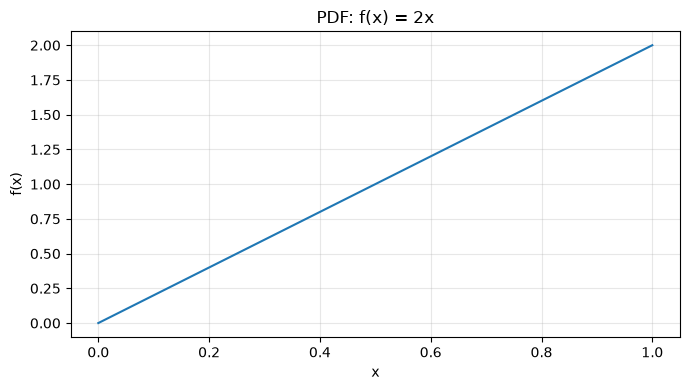

In [ ]:
x = np.linspace(0, 1, 200)

pdf = 2 * x
cdf = x ** 2

plt.figure(figsize=(7, 4))
plt.plot(x, pdf)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title("PDF: f(x) = 2x")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

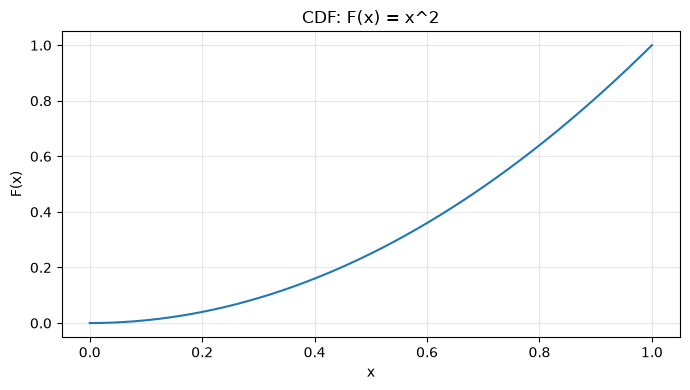

In [5]:
plt.figure(figsize=(7,4))
plt.plot(x, cdf)
plt.xlabel('x')
plt.ylabel('F(x)')
plt.title("CDF: F(x) = x^2")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation of the PDF and CDF

The PDF describes how peobability density changes across the support.

The CDF accumulates probability from the left side of the support up to a chosen value $x$.

For this distribution, 

$$
F(x)=x^2.
$$

For example, at

$$
x=\frac12,
$$

the accumulated probability is

$$
F\left(\frac12\right)
=
\left(\frac12\right)^2
=
\frac14.
$$

Therefore, one observation has probability

$$
P\left(X\le\frac12\right)=\frac14.
$$

This value will become the success probability in the Binomial model.


## Investigation 5 — Calculate the Order-Statistic Probability

Suppose

$$
n=5,\qquad r=4,\qquad y=\frac12.
$$

The target probability is

$$
P\left(Y_{(4)}\le\frac12\right).
$$

First, the probability that one observation is below the threshold is

$$
p
=
F\left(\frac12\right)
=
\frac14.
$$

Therefore, the count of observations below the threshold follows

$$
K\sim\operatorname{Binomial}\left(5,\frac14\right).
$$

The order-statistic event is equivalent to

$$
Y_{(4)}\le\frac12
\quad\Longleftrightarrow\quad
K\ge4.
$$

Therefore,

$$
P\left(Y_{(4)}\le\frac12\right)
=
P(K=4)+P(K=5).
$$

For exactly four observations,

$$
P(K=4)
=
\binom54
\left(\frac14\right)^4
\left(\frac34\right).
$$

This gives

$$
P(K=4)=\frac{15}{1024}.
$$

For exactly five observations,

$$
P(K=5)
=
\binom55
\left(\frac14\right)^5
=
\frac{1}{1024}.
$$

Therefore,

$$
P\left(Y_{(4)}\le\frac12\right)
=
\frac{15}{1024}
+
\frac{1}{1024}
=
\frac{16}{1024}.
$$

Simplifying,

$$
P\left(Y_{(4)}\le\frac12\right)
=
\frac1{64}
=
0.015625.
$$

The $K=5$ case must be included because all five observations being below $0.5$ still guarantees that the fourth smallest observation is below $0.5$.

**Small expression:** *Substituting these values gives...*

In [8]:
from math import comb

n = 5
r = 4
y = 0.5

p = y**2

probability = 0

for k in range(r, n + 1):
    prob_k = comb(n, k) * (p ** k) * ((1 - p) ** (n - k))

    print(f"P(K= {k}) = {prob_k}")

    probability += prob_k

print(f"P(Y_(4) <= {y}) = {probability}")

P(K= 4) = 0.0146484375
P(K= 5) = 0.0009765625
P(Y_(4) <= 0.5) = 0.015625


### Validation

The Python calculation gives

$$
0.015625
$$

which is the same as the hand calculation.

This is validates the artihmetic, but it does not yet test the deeper clain that the ranking event and counting event are equivalent.

Next, I will test that relationship directly using simulation.

In [10]:
from scipy.stats import binom

library_probability = binom.sf(r - 1, n, p)  # r = 4.

print(library_probability)

0.015625


### From-Scratch vs. Library Calculation

The from-scratch calculation and SciPy give the same result:

$$
P\left(Y_{(4)}\le\frac12\right)=0.015625.
$$

Writing the Binomial sum myself was useful for understanding why both $K=4$ and $K=5$ must be included.


## Investigation 6 — Verify Ranking vs. Counting by Simulation

So far, I have derived the probability mathematically.

Now I want to test the central logical claim empirically.

I will compare two events.

### Event A: Order-statistic condition

$$
Y_{(4)}\le0.5
$$

### Event B: Counting condition

$$
\#\{X_i\le0.5\}\ge4
$$

### Hypothesis

For every simulated sample, these two events should have exactly the same truth value.

The original CDF is

$$
F(x)=x^2.
$$

To generate samples from this distribution, let

$$
U\sim\operatorname{Uniform}(0,1).
$$

Since

$$
U=F(X)=X^2,
$$

solving for $X$ gives

$$
X=\sqrt{U}.
$$

Therefore, I can generate observations from the required distribution by generating uniform random numbers and taking their square roots.


In [42]:
# Use the seed for reproducibility
rng = np.random.default_rng(132)

n_simulations = 100000
n = 5    # 5 observations in each experiment
r = 4
threshold = 0.5

# Generate uniform random samples.
u = rng.random((n_simulations, n))

samples = np.sqrt(u)

samples.shape

(100000, 5)

In [43]:
# Sort the uniform random samples.
sorted_samples = np.sort(samples, axis =1)
# Take the 4th smallest value. 
y4 = sorted_samples[:, 3]

event_order_stat = y4 <= threshold

In [44]:
sorted_samples[:5]

array([[0.37762591, 0.86324043, 0.89703168, 0.91434125, 0.93934635],
       [0.53930221, 0.73361076, 0.78095448, 0.9698475 , 0.9849756 ],
       [0.45460216, 0.77206706, 0.98346631, 0.99336285, 0.99337666],
       [0.07662529, 0.45186977, 0.45215161, 0.87103644, 0.97510335],
       [0.47664319, 0.78599644, 0.87116047, 0.88768243, 0.89614965]])

In [45]:
y4[:5]

array([0.91434125, 0.9698475 , 0.99336285, 0.87103644, 0.88768243])

In [46]:
#samples: randomly generated samples from the uniform distribution    
count_below = np.sum(samples <= threshold, axis=1)

event_count = count_below >= r

In [47]:
count_below[:10]

array([1, 0, 1, 3, 1, 2, 0, 1, 0, 1])

In [48]:
#event_order_stat: boolean array indicating whether the 4th order statistic is less than or equal to the threshold
#event_count: boolean array indicating whether the count of samples less than or equal to the threshold is greater than or equal to r
same_events = np.array_equal(event_order_stat, event_count)

print(f"Are the two events identical? {same_events}")

Are the two events identical? True


In [49]:
simulated_probability_order = np.mean(event_order_stat)
simulated_probability_count = np.mean(event_count)

#
theoretical_probability = 1 / 64
#0.015625

print(f"Theoretical probability: {theoretical_probability}")
print(f"Simulation using order statistic: {simulated_probability_order}")
print(f"Simulation using count: {simulated_probability_count}")

Theoretical probability: 0.015625
Simulation using order statistic: 0.01595
Simulation using count: 0.01595


### Simulation Result

The order-statistic condition and the counting condition were identical for every simulated sample.

In other words,

$$
Y_{(4)}\le0.5
$$

and

$$
\#\{X_i\le0.5\}\ge4
$$

identified exactly the same simulated outcomes.

The simulated probability was also close to the theoretical probability

$$
\frac1{64}=0.015625.
$$

The small difference between the theoretical and simulated probabilities is expected because the simulation uses a finite number of random samples.

### Interpretation

The simulation provides empirical evidence for the same relationship established mathematically:

$$
Y_{(r)}\le y
\quad\Longleftrightarrow\quad
\#\{X_i\le y\}\ge r.
$$

The order statistic describes the event through **ranking**, while the Binomial variable describes the same event through **counting**.


## Results / Findings

The main findings from this investigation are:

1. $Y_{(r)}$ refers to the $r$-th smallest observation after sorting.
2. $Y_{(r)}\le y$ does not mean exactly $r$ observations are below $y$.
3. It means that at least $r$ observations are below $y$.
4. The number of observations satisfying $X_i\le y$ can be represented by a Binomial random variable.
5. The Binomial success probability is $F(y)$.
6. For $f(x)=2x$ on $0<x<1$, the CDF is $F(x)=x^2$.
7. The theoretical calculation and Python simulation produced consistent results.

The most important relationship is

$$
Y_{(r)}\le y
\quad\Longleftrightarrow\quad
K\ge r.
$$



## Interpretation

At first, order statistics and the Binomial distribution seemed like separate ideas.

The connection becomes clearer when I introduce a threshold $y$.

For each observation, I can ask whether

$$
X_i\le y.
$$

This converts every observation into a success/failure outcome.

The CDF gives the probability of success:

$$
P(X_i\le y)=F(y).
$$

The Binomial distribution then counts how many observations are successful.

If at least $r$ observations are less than or equal to $y$, then after sorting the observations, the $r$-th smallest observation must also be less than or equal to $y$.

This gives the chain

$$
f(x)
\longrightarrow
F(y)
\longrightarrow
P(X_i\le y)
\longrightarrow
K
\longrightarrow
P(K\ge r)
\longrightarrow
P(Y_{(r)}\le y).
$$

The key idea is that **ranking and counting provide two different descriptions of the same event**.


## What Changed in My Understanding

| Before | After |
|---|---|
| I thought $Y_{(4)}\le0.5$ meant exactly four observations were below $0.5$. | I now understand that it means at least four observations are below $0.5$. |
| I did not understand why the case with all five observations below $0.5$ was included. | The fifth observation does not change the fact that the fourth smallest observation is below $0.5$. |
| I saw the Binomial distribution as a separate formula. | I now see it as a way to count observations that cross a threshold. |
| I was unsure why $F(y)$ appeared in the Binomial formula. | $F(y)$ is the probability that one observation satisfies $X_i\le y$. |
| I thought integrating over the full support might be necessary for the CDF. | The CDF integrates only up to the value whose cumulative probability I want. |

The biggest change in my understanding is that an order-statistic probability can often be easier to understand by changing the perspective from **position after sorting** to **number of observations crossing a threshold**.


## Remaining Questions

This notebook focused mainly on understanding the CDF of an order statistic through counting.

A natural next question is:

> How can the PDF of the $r$-th order statistic be derived from its CDF?

The general CDF is

$$
G_r(y)
=
P(Y_{(r)}\le y)
=
\sum_{k=r}^{n}
\binom{n}{k}
[F(y)]^k
[1-F(y)]^{n-k}.
$$

The general PDF is

$$
g_r(y)
=
\frac{n!}{(r-1)!(n-r)!}
[F(y)]^{r-1}
[1-F(y)]^{n-r}
f(y).
$$

I will leave the detailed derivation of this PDF for a later investigation rather than adding too much to this notebook.

In [51]:
print("Theoretical:", theoretical_probability)
print("From scratch:", probability)
print("SciPy:", library_probability)
print("Simulation:", simulated_probability_order)
print("Event equivalence:", same_events)

Theoretical: 0.015625
From scratch: 0.015625
SciPy: 0.015625
Simulation: 0.01595
Event equivalence: True
